### Task 1 :-  Performing Analysis using tool DASK the data set here used is from kaggle which contain 2million row 
https://www.kaggle.com/datasets/hunter0007/ecommerce-dataset-for-predictive-marketing-2023

In [108]:
import dask.dataframe as dd
import pandas as pd
import numpy as np

In [2]:
pd = pd.read_csv(
    r"C:\Users\User\Desktop\Life Disk\Data Analysis\Codetech internship\e_commerce.csv"  
)

In [3]:
#Used dask
df = dd.read_csv(
    r"C:\Users\User\Desktop\Life Disk\Data Analysis\Codetech internship\e_commerce.csv"  
)

In [4]:
df.shape[0].compute(),df.shape[1]

(2019501, 12)

In [5]:
df.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,department_id,department,product_name
0,2425083,49125,1,2,18,NaN,17,1,0,13,pantry,baking ingredients
1,2425083,49125,1,2,18,NaN,91,2,0,16,dairy eggs,soy lactosefree
2,2425083,49125,1,2,18,NaN,36,3,0,16,dairy eggs,butter
3,2425083,49125,1,2,18,NaN,83,4,0,4,produce,fresh vegetables
4,2425083,49125,1,2,18,NaN,83,5,0,4,produce,fresh vegetables


### Description of Table
- Order_id = Unique identifier of order
- user_id = unique identifier for each user
- order number = the number that represnt that how many time user has purchased
- order = day of the week
- order_hours_of the day = the hours of the day
- days_since_prior_order = Gap taken to reorder
- product_id = ID of the product
- add_to_cart_order = Number of item added to cart
- reordered	= Item reordered count
- department_id	= Unique identifier of department
- department =Name of department
- product_name = Product name 

### Objective:
To retrieve meaningful information from the dataset by performing data cleaning, exploration, and analysis, in order to generate actionable insights that support better decision-making.

### Cleaning and Exploring data 

In [6]:
df.info()

<class 'dask.dataframe.dask_expr.DataFrame'>
Columns: 12 entries, order_id to product_name
dtypes: float64(1), int64(9), string(2)

In [7]:
pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019501 entries, 0 to 2019500
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   order_number            int64  
 3   order_dow               int64  
 4   order_hour_of_day       int64  
 5   days_since_prior_order  float64
 6   product_id              int64  
 7   add_to_cart_order       int64  
 8   reordered               int64  
 9   department_id           int64  
 10  department              object 
 11  product_name            object 
dtypes: float64(1), int64(9), object(2)
memory usage: 184.9+ MB


In [8]:
df.describe().round(2).compute()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,department_id
count,2019501.00,2019501.00,2019501.00,2019501.00,2019501.00,1895159.00,2019501.00,2019501.00,2019501.00,2019501.00
mean,1707012.76,103067.27,17.15,2.74,13.44,11.39,71.21,8.36,0.59,9.93
std,985983.20,59491.17,17.53,2.09,4.24,8.97,38.21,7.15,0.49,6.28
min,10.00,2.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00
25%,852649.00,51584.00,5.00,1.00,10.00,5.00,31.00,3.00,0.00,4.00
50%,1705004.00,102690.00,11.00,3.00,13.00,8.00,83.00,6.00,1.00,9.00
75%,2559031.00,154600.00,24.00,5.00,16.00,15.00,107.00,11.00,1.00,16.00
max,3421080.00,206209.00,100.00,6.00,23.00,30.00,134.00,137.00,1.00,21.00


##### Order Day of Week: it shows 50% are 3 and mean 2.74 so almost its on mid day of the week customer order and there who order on 6th day 
##### Order Hour of Day: mean 13.44 and 75% around mid day of the hour and there are orders on late night 
##### Days Since Prior Order: so here it takes almost 11 days to order again and there customer who buys within 5 days and also who takes even 30 days to order again
##### Department ID:customers purchase from a wide range of departments.

In [9]:
df.isnull().sum().compute()   #exploring the nulls

order_id                       0
user_id                        0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    124342
product_id                     0
add_to_cart_order              0
reordered                      0
department_id                  0
department                     0
product_name                   0
dtype: int64

In [10]:
# Presence of nulls in days_since_prior_order represents the first purchase will be replacing with 0 
df['days_since_prior_order'] = df['days_since_prior_order'].fillna(0)

In [11]:
df.isnull().sum().compute()

order_id                  0
user_id                   0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_id                0
add_to_cart_order         0
reordered                 0
department_id             0
department                0
product_name              0
dtype: int64

In [12]:
df = df.rename(columns={
    'days_since_prior_order': 'reorder_gap_days'  #renamed for better understanding
})

In [13]:
df.columns

Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'reorder_gap_days', 'product_id', 'add_to_cart_order', 'reordered',
       'department_id', 'department', 'product_name'],
      dtype='object')

In [14]:
df['order_id'].nunique()

<dask_expr.expr.Scalar: expr=(DropDuplicates(frame=(RenameFrame(frame=Assign(frame=ArrowStringConversion(frame=FromMapProjectable(8b86bec))), columns={'days_since_prior_order': 'reorder_gap_days'}))['order_id'], split_every=False)).count(), dtype=int64>

In [15]:
cols = ['product_name', 'department']

for col in cols:                                  
    df[col] = df[col].str.strip()

In [16]:
cols = ['department', 'product_name']

for col in cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [17]:
df['department'].unique()

Dask Series Structure:
npartitions=1
    object
       ...
Dask Name: unique, 24 expressions
Expr=Unique(frame=(Assign(frame=Assign(frame=Assign(frame=Assign(frame=RenameFrame(frame=Assign(frame=ArrowStringConversion(frame=FromMapProjectable(8b86bec))), columns={'days_since_prior_order': 'reorder_gap_days'}))))))['department'])

In [18]:
df['product_name'].nunique().compute()

np.int64(134)

In [19]:
duplicate_count = len(df) - len(df.drop_duplicates())

In [20]:
duplicate_count

0

In [21]:
df.shape[0].compute(),df.shape[1]

(2019501, 12)

In [22]:
type(df)

dask.dataframe.dask_expr._collection.DataFrame

In [23]:
check_dup = df.drop_duplicates(subset=['order_id', 'product_name'])

print(check_dup.head(10))

    order_id  user_id  order_number  order_dow  order_hour_of_day  \
0    2425083    49125             1          2                 18   
1    2425083    49125             1          2                 18   
2    2425083    49125             1          2                 18   
3    2425083    49125             1          2                 18   
6    2425083    49125             1          2                 18   
7    2425083    49125             1          2                 18   
8    2425083    49125             1          2                 18   
9    1944304   162867             1          3                 17   
10   1944304   162867             1          3                 17   
11   1944304   162867             1          3                 17   

    reorder_gap_days  product_id  add_to_cart_order  reordered  department_id  \
0                0.0          17                  1          0             13   
1                0.0          91                  2          0             16 

##### “Repeated product rows can represent quantity, not duplication.”

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

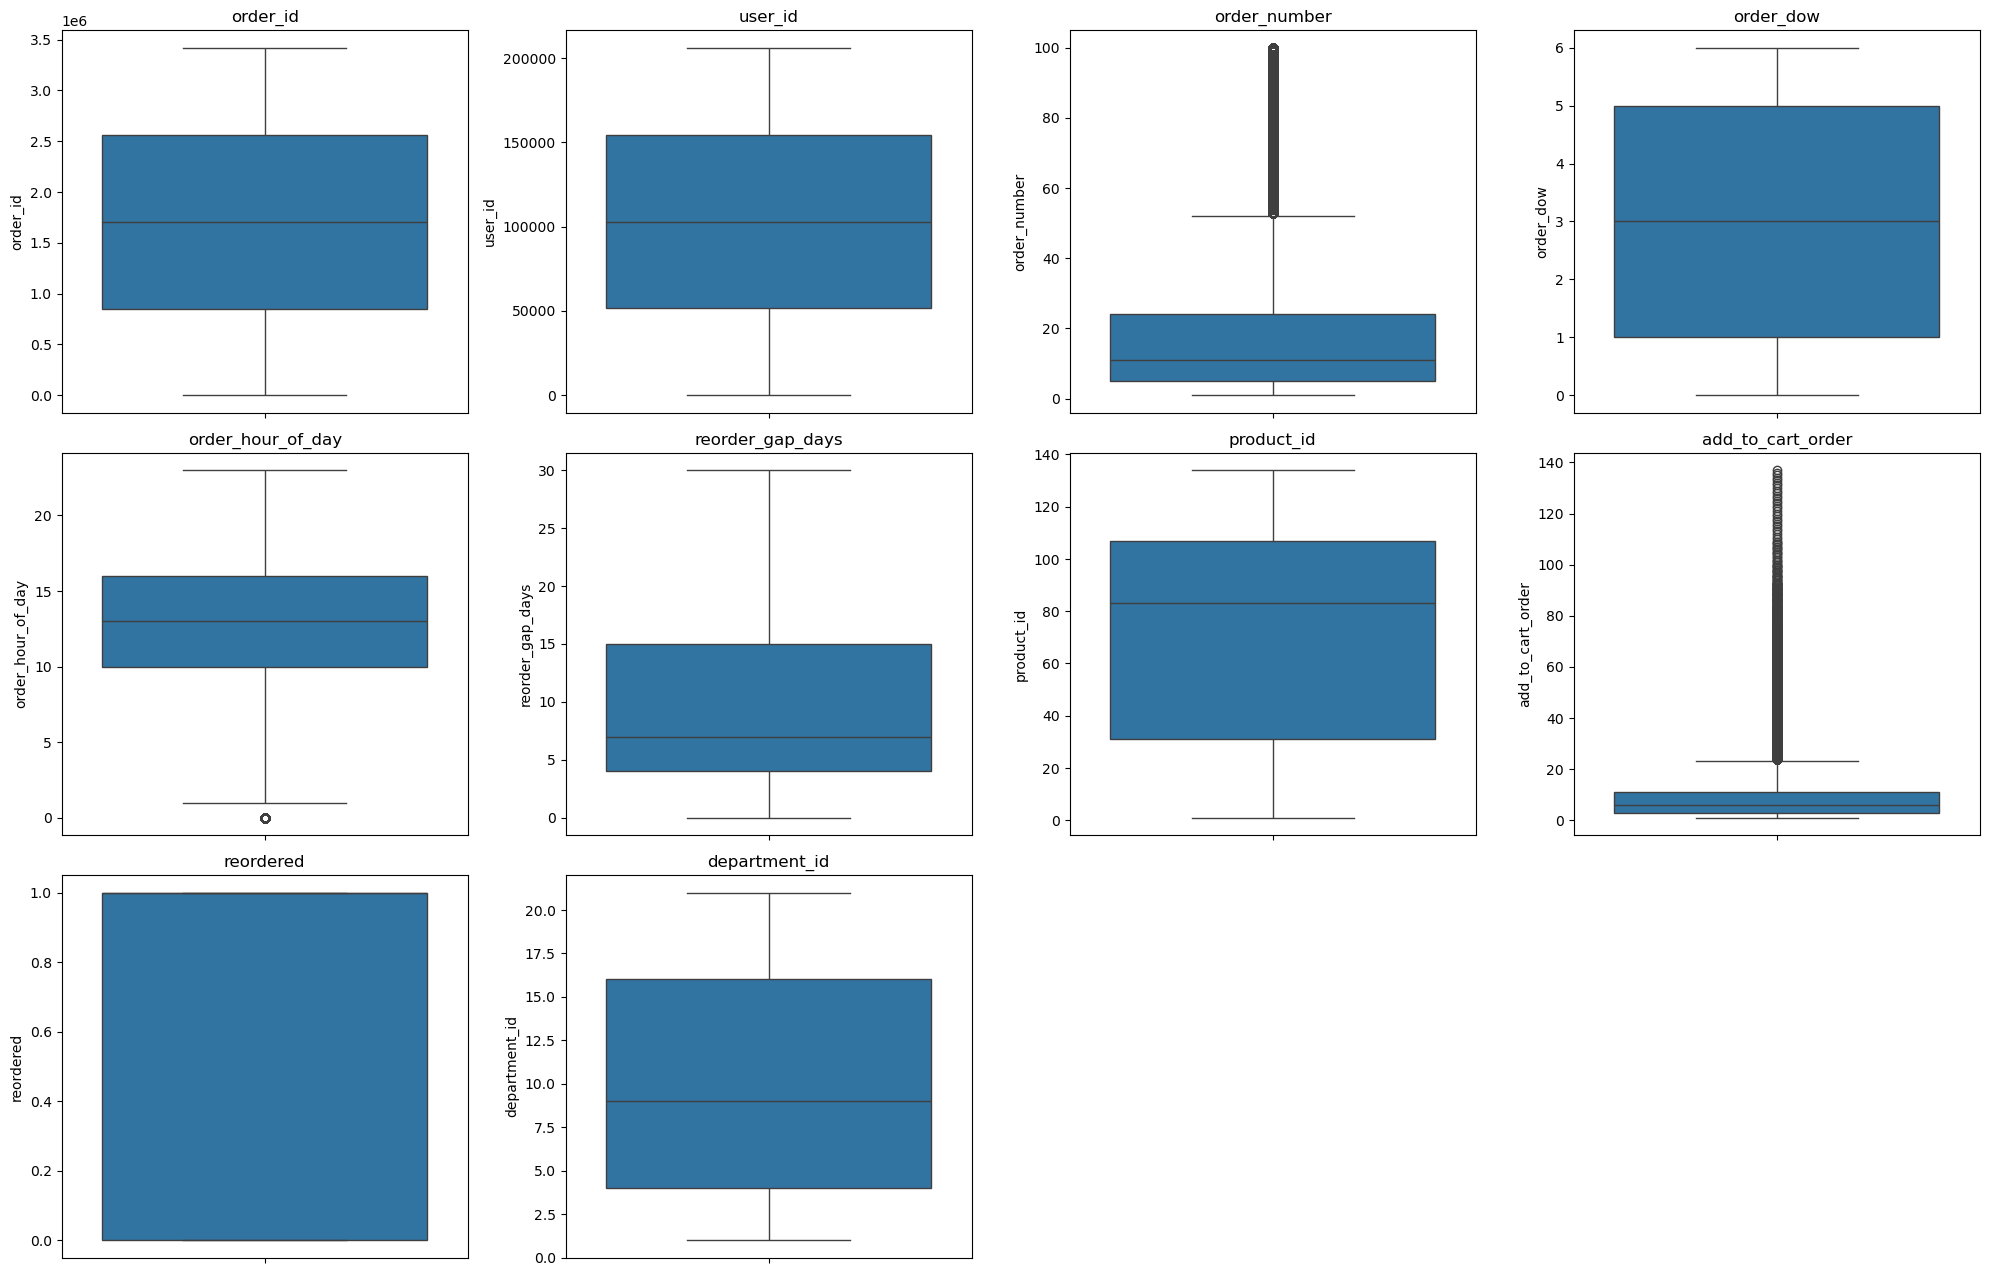

In [25]:
# outlier Detection with Boxplots
numericals_cols = df.select_dtypes(include = 'number').columns

plt.figure(figsize=(20,17))
for i, col in enumerate(numericals_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

- Order Number
Right-skewed distribution indicates that while most customers place a small number of orders, a smaller group of customers places a high volume of orders (bulk or frequent buyers).
- Order Day of Week (order_dow)
Orders are fairly evenly distributed across the week, suggesting no strong preference for a specific day. Customer purchasing behavior is consistent throughout the week.
- Order Hour of Day (order_hour_of_day)
Orders occur across various hours, indicating customers shop at different times of the day. (You can improve this further if you identify peak hours.)
- Reorder Gap (reorder_days)
Right-skewed distribution with the mean closer to the lower range suggests most customers reorder within 5–11 days, while a smaller group takes longer to reorder.
- Add to Cart Order (add_to_cart_order)
Right-skewed distribution indicates most customers add a moderate number of items, but some customers add a significantly larger number of products (bulk shopping behavior).
- Department ID
Slight skewness suggests that certain departments are more frequently visited/purchased than others, indicating uneven demand across product categories.

In [26]:
df.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,reorder_gap_days,product_id,add_to_cart_order,reordered,department_id,department,product_name
0,2425083,49125,1,2,18,0.0,17,1,0,13,pantry,baking ingredients
1,2425083,49125,1,2,18,0.0,91,2,0,16,dairy eggs,soy lactosefree
2,2425083,49125,1,2,18,0.0,36,3,0,16,dairy eggs,butter
3,2425083,49125,1,2,18,0.0,83,4,0,4,produce,fresh vegetables
4,2425083,49125,1,2,18,0.0,83,5,0,4,produce,fresh vegetables


### Data Analysis 

In [349]:
# Which products are purchased the most?
df.groupby('product_name').size().compute().sort_values(ascending=False)

product_name
fresh fruits                  226039
fresh vegetables              212611
packaged vegetables fruits    109596
yogurt                         90751
packaged cheese                61502
                               ...  
kitchen supplies                 561
baby bath body care              515
baby accessories                 504
beauty                           387
frozen juice                     279
Length: 134, dtype: int64

In [350]:
#Which departments have the highest number of orders?
dep_df = df.groupby('department').size().compute().sort_values(ascending=False)

In [351]:
dep_df = dep_df.reset_index()

In [354]:
dep_df = dep_df.rename(columns ={0:'count'})

dep_df

,department,count
0,produce,588996
1,dairy eggs,336915
2,snacks,180692
3,beverages,168126
4,frozen,139536
5,pantry,116262
6,bakery,72983
7,canned goods,66053
8,deli,65176
9,dry goods pasta,54054


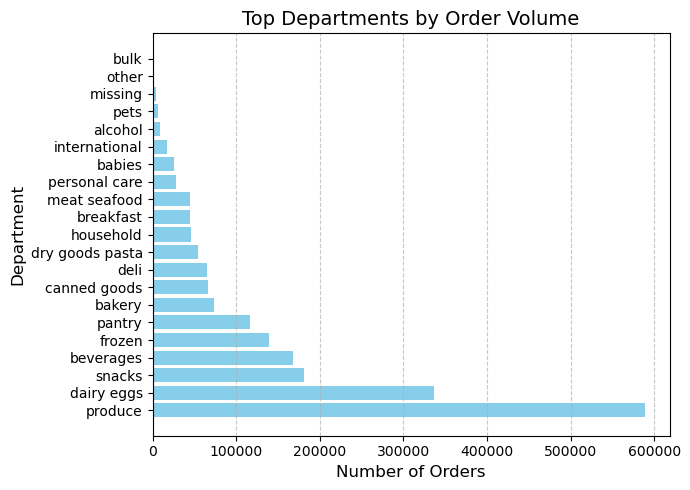

In [358]:
plt.figure(figsize=(7, 5))
plt.barh(dep_df['department'], dep_df['count'], color='skyblue')

# 4. Styling
plt.title('Top Departments by Order Volume', fontsize=14)
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('Department', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

- Since these are online purchases, the focus is heavily geared toward essentials.
- Produce (588,996) is overwhelmingly your top category. This suggests a high level of trust in the service's quality control for fresh items.
- The strength of Snacks (180,692), Beverages (168,126), and Frozen (139,536) shows that users often use online shopping to manage bulky items (like cases of water or soda) and long-shelf-life goods that are easy to pick by brand name.
- Alcohol (9,439), Pets (6,013), and Bulk (2,133) this indicates Niche Needs are less

In [31]:
#which user has maximum reordered
top_users = df.groupby('user_id')['reordered'].sum().compute().sort_values(ascending=False).head(10)

In [32]:
top_users

user_id
129928    368
176478    346
201268    332
126305    330
115495    243
100330    239
31903     235
105213    217
203166    209
193539    206
Name: reordered, dtype: int64

In [33]:
filtered = df[df['user_id'].isin(top_users.index)]

In [34]:
# Top users focused on what type of department
department_focus =filtered[['user_id','department']].compute()

In [35]:
department_focus = department_focus.groupby('user_id')['department'].value_counts()

In [36]:
department_focus = department_focus.reset_index()

In [37]:
department_focus

,user_id,department,count
0,31903,dairy eggs,74
1,31903,produce,52
2,31903,deli,27
3,31903,bakery,23
4,31903,snacks,19
...,...,...,...
117,203166,snacks,33
118,203166,beverages,16
119,203166,produce,16
120,203166,breakfast,13


C:\Users\User\AppData\Local\Temp\ipykernel_3132\2800381855.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=department_focus, x='department', y='count', palette="crest")


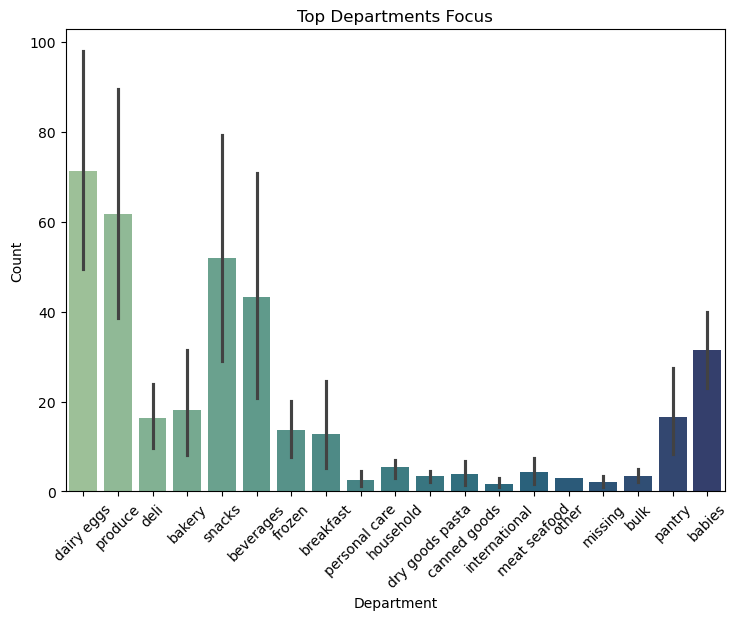

In [38]:
plt.figure(figsize=(8.5,6))
sns.barplot(data=department_focus, x='department', y='count', palette="crest")

plt.title("Top Departments Focus")
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [39]:
# Top 10 users focused on what kind of product 
prod_focus = filtered[['user_id','product_name']].compute()

In [40]:
prod_focus.groupby('user_id')['product_name'].apply(list).reset_index()

,user_id,product_name
0,31903,"[fresh fruits, water seltzer sparkling water, ..."
1,100330,"[tea, yogurt, coffee, tea, refrigerated, fresh..."
2,105213,"[fresh fruits, fresh vegetables, fresh fruits,..."
3,115495,"[fresh fruits, fresh fruits, soy lactosefree, ..."
4,126305,"[salad dressing toppings, pickled goods olives..."
5,129928,"[refrigerated, water seltzer sparkling water, ..."
6,176478,"[soy lactosefree, soy lactosefree, soy lactose..."
7,193539,"[fresh fruits, eggs, prepared meals, chips pre..."
8,201268,"[nuts seeds dried fruit, tea, eggs, soy lactos..."
9,203166,"[cream, fresh dips tapenades, popcorn jerky, p..."


In [41]:
df.head(2)

,order_id,user_id,order_number,order_dow,order_hour_of_day,reorder_gap_days,product_id,add_to_cart_order,reordered,department_id,department,product_name
0,2425083,49125,1,2,18,0.0,17,1,0,13,pantry,baking ingredients
1,2425083,49125,1,2,18,0.0,91,2,0,16,dairy eggs,soy lactosefree


In [42]:
df.columns     #since i need to scroll back to top just called the column

Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'reorder_gap_days', 'product_id', 'add_to_cart_order', 'reordered',
       'department_id', 'department', 'product_name'],
      dtype='object')

In [406]:
# What is the maximum number of items added to a cart in a single order?
max_to_cart = df.groupby('order_id')['add_to_cart_order'].max()


In [407]:
max_to_cart = max_to_cart.reset_index().compute()

In [408]:
max_to_cart.head(10)

,order_id,add_to_cart_order
0,10,15
1,11,5
2,28,16
3,38,9
4,56,10
5,62,7
6,64,5
7,110,10
8,122,2
9,140,9


In [409]:
max_to_cart['add_to_cart_order'].describe()

count    200000.000000
mean         10.097505
std           7.539068
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         137.000000
Name: add_to_cart_order, dtype: float64

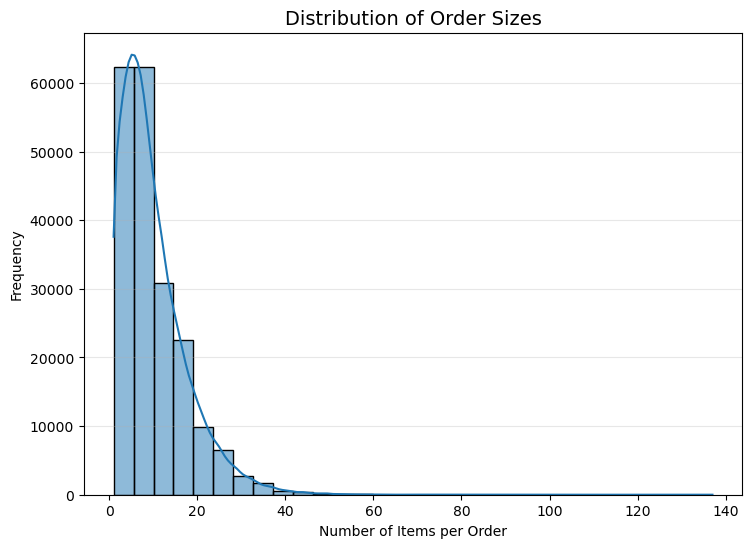

In [410]:
plt.figure(figsize=(8.5, 6))

sns.histplot(
    max_to_cart['add_to_cart_order'],
    bins=30,
    kde=True
)

plt.title('Distribution of Order Sizes', fontsize=14)
plt.xlabel('Number of Items per Order')
plt.ylabel('Frequency')

plt.grid(axis='y', alpha=0.3)
plt.show()

##### The majority of orders are small, with a median basket size of 8 items and 75% of orders containing fewer than 14 items. However, a small number of extreme bulk orders (up to 137 items) create a long right tail, indicating occasional high-volume purchasing behavior

In [53]:
# Highest Reorder_product
reorder_prod =  df.groupby('product_name')['reordered'].mean()

In [54]:
reorder_prod = reorder_prod.reset_index().compute()

In [55]:
reorder_prod = reorder_prod.sort_values(by = 'reordered', ascending=False)

In [56]:
reorder_prod .head(10)

,product_name,reordered
83,milk,0.782629
131,water seltzer sparkling water,0.731813
50,fresh fruits,0.718261
41,eggs,0.707425
119,soy lactosefree,0.691843
96,packaged produce,0.690545
33,cream,0.688618
133,yogurt,0.688301
11,bread,0.674528
110,refrigerated,0.664586


In [57]:
# Highest Reorder department 
reorder_dep =  df.groupby('department')['reordered'].mean()

In [58]:
reorder_dep = reorder_dep.reset_index().compute()
reorder_dep = reorder_dep.sort_values(by = 'reordered', ascending=False)
reorder_dep.head(10)

,department,reordered
7,dairy eggs,0.670193
3,beverages,0.654967
19,produce,0.649283
2,bakery,0.629859
8,deli,0.612449
18,pets,0.604357
1,babies,0.580918
5,bulk,0.576653
20,snacks,0.574370
13,meat seafood,0.572067


In [59]:
# Top peak hours
top_peak_hours = df['order_hour_of_day'].value_counts().compute()

In [63]:
top_peak_hours = top_peak_hours .reset_index()

In [65]:
top_peak_hours = top_peak_hours.sort_values(by='count',ascending=False).head(10)

In [66]:
top_peak_hours

,order_hour_of_day,count
10,10,173306
11,11,170291
14,14,167831
15,15,167157
13,13,166376
12,12,163511
16,16,158247
9,9,150248
17,17,129383
8,8,106754


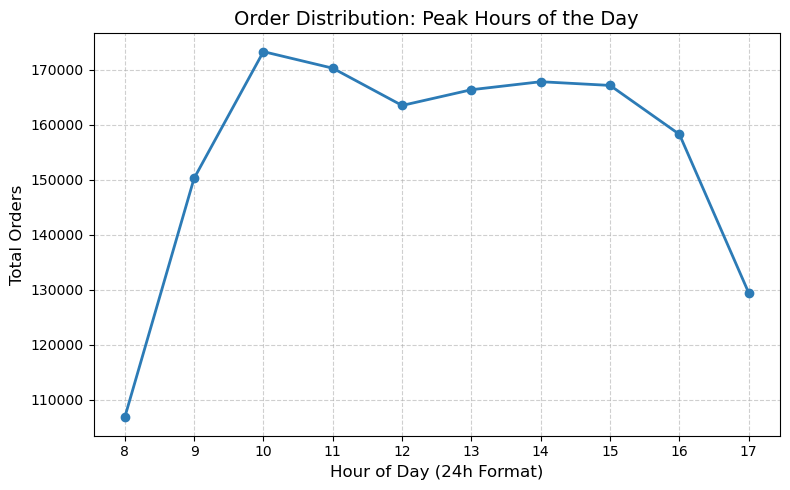

In [345]:
top_peak_hours = top_peak_hours.sort_values('order_hour_of_day')

plt.figure(figsize=(8, 5))
plt.plot(top_peak_hours['order_hour_of_day'], top_peak_hours['count'], 
         marker='o', linestyle='-', color='#2c7bb6', linewidth=2)

# Adding labels and styling
plt.title('Order Distribution: Peak Hours of the Day', fontsize=14)
plt.xlabel('Hour of Day (24h Format)', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(top_peak_hours['order_hour_of_day'])

plt.tight_layout()
plt.show()

In [206]:
#which is the most focused product during peak hours
dep_foc = df[df['order_hour_of_day'].isin(top_peak_hours['order_hour_of_day'])]

In [207]:
dep_foc = dep_foc[['order_hour_of_day', 'department']].compute()

In [208]:
dep_foc = dep_foc.groupby('department').size().reset_index()

In [209]:
dep_foc = dep_foc.rename(columns={0: 'count'})

In [211]:
dep_foc.sort_values(by='count',ascending=False)

,department,count
19,produce,451800
7,dairy eggs,258623
20,snacks,141499
3,beverages,131229
10,frozen,105071
16,pantry,89176
2,bakery,56449
6,canned goods,51041
8,deli,50148
9,dry goods pasta,41505


In [220]:
#which is the most focused product during late night
late_night_order = df[
    (df['order_hour_of_day'] >= 22) |
    (df['order_hour_of_day'] <= 2)
]

In [222]:
late_night = late_night_order.compute()

In [223]:
late_night = df[df['order_hour_of_day'].isin(late_night_order['order_hour_of_day'])]

In [224]:
late_night= late_night[['order_hour_of_day', 'department']].compute()

In [227]:
late_night = late_night.groupby('department').size()

In [230]:
late_night = late_night.reset_index()

In [232]:
late_night = late_night.rename(columns={0: 'count'})

In [233]:
late_night.sort_values(by='count',ascending=False)

,department,count
19,produce,27971
7,dairy eggs,14810
20,snacks,7374
3,beverages,6728
10,frozen,6409
16,pantry,5486
6,canned goods,3065
2,bakery,2961
8,deli,2844
9,dry goods pasta,2573


##### From both peak hours and late night the products and department focused are on essential items :- 
- produce,dairy eggs,snacks,bevergaes,frozen,pntry,bakery

In [419]:
# During which day of week the most order happens
top_dow = df.groupby('order_dow')['order_id'].count().compute()
top_dow = top_dow.sort_values(ascending=False)
top_dow  

order_dow
0    391831
1    349236
6    280751
5    262157
2    261912
3    238730
4    234884
Name: order_id, dtype: int64

In [417]:
day_map = {
    0: 'Sunday', 1: 'Monday', 2: 'Tuesday',
    3: 'Wednesday', 4: 'Thursday',
    5: 'Friday', 6: 'Saturday'
}

top_dow.index = top_dow.index.map(day_map)
top_dow = top_dow.rename('count')

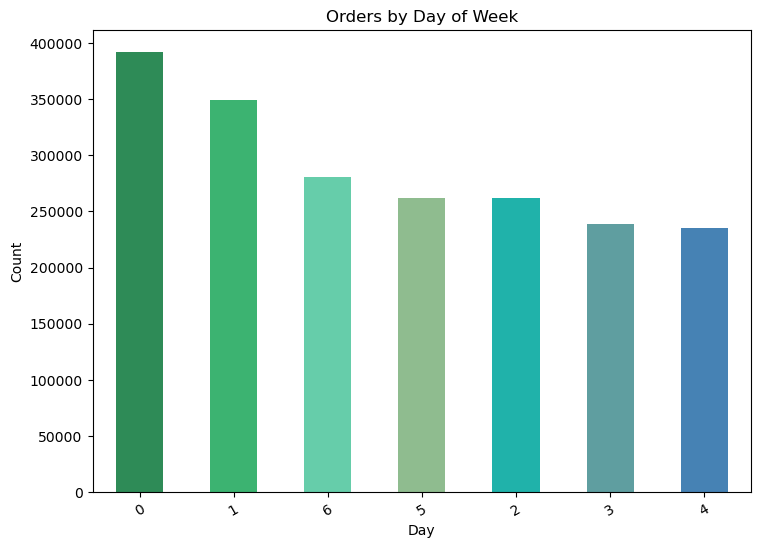

In [421]:
colors = ['#2e8b57', '#3cb371', '#66cdaa', '#8fbc8f', '#20b2aa', '#5f9ea0', '#4682b4']

top_dow.plot(kind='bar', figsize=(8.5,6), color=colors)

plt.title('Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

Order volume is highest on Sunday, followed by Monday, indicating strong shopping activity at the start of the week. There is a gradual decline in orders through midweek, with the lowest activity observed on Thursday. A slight increase is seen again on Friday and Saturday, suggesting early weekend shopping behavior.

In [237]:
product_day = df.groupby(['order_dow', 'product_name'])['order_id'].count().compute()
product_day = product_day.reset_index(name='count')

In [241]:
top_products = (
    product_day.sort_values(['order_dow', 'count'], ascending=[True, False])
    .groupby('order_dow')
    .head(2)
)
top_products

,order_dow,product_name,count
53,0,fresh vegetables,46643
50,0,fresh fruits,44727
184,1,fresh fruits,41126
187,1,fresh vegetables,36440
318,2,fresh fruits,28830
321,2,fresh vegetables,26481
452,3,fresh fruits,26102
455,3,fresh vegetables,23243
586,4,fresh fruits,25744
589,4,fresh vegetables,22914


In [240]:
day_dept = df.groupby(['order_dow', 'department'])['order_id'].count().compute()

day_dept = day_dept.reset_index(name='count')

In [249]:
top_dept_per_day = (
    day_dept.sort_values(['order_dow', 'count'], ascending=[True, False])
    .groupby('order_dow')
    .head(1)
)
top_dept_per_day

,order_dow,department,count
19,0,produce,122185
40,1,produce,103835
61,2,produce,74381
82,3,produce,66510
103,4,produce,65814
124,5,produce,73188
145,6,produce,83083


### Basket Analysis

In [384]:
basket_analysis = df.groupby('order_id')['product_name'].apply(list, meta=('product_name', 'object'))

In [385]:
basket_analysis = basket_analysis.compute().reset_index()

In [422]:
basket_analysis = basket_analysis['product_name'].tolist()

In [425]:
basket_analysis[:5]

[['meat counter',
  'fresh herbs',
  'canned meals beans',
  'baby food formula',
  'fresh fruits',
  'cream',
  'fresh vegetables'],
 ['fresh dips tapenades',
  'canned meals beans',
  'chips pretzels',
  'frozen meals',
  'oils vinegars'],
 ['butter',
  'poultry counter',
  'fresh fruits',
  'cream',
  'milk',
  'yogurt',
  'fresh vegetables',
  'packaged cheese',
  'spreads',
  'other creams cheeses'],
 ['nuts seeds dried fruit',
  'fresh herbs',
  'packaged vegetables fruits',
  'fresh vegetables',
  'frozen produce',
  'oils vinegars'],
 ['fresh fruits',
  'refrigerated',
  'doughs gelatins bake mixes',
  'canned jarred vegetables',
  'cream',
  'packaged vegetables fruits',
  'fresh vegetables',
  'packaged cheese',
  'frozen produce',
  'eggs']]

In [392]:
basket_analysis['product_name'] = basket_analysis['product_name'].apply(lambda x: list(set(x)))

In [393]:
from itertools import combinations
from collections import Counter

pair_counter = Counter()

for basket in basket_analysis['product_name']:
    pairs = combinations(basket, 2)
    pair_counter.update(pairs)

top_pairs = pair_counter.most_common(20)
top_pairs

[(('fresh fruits', 'fresh vegetables'), 58733),
 (('fresh fruits', 'packaged vegetables fruits'), 53568),
 (('packaged vegetables fruits', 'fresh vegetables'), 44260),
 (('fresh fruits', 'yogurt'), 35730),
 (('fresh fruits', 'milk'), 32611),
 (('fresh fruits', 'packaged cheese'), 30227),
 (('yogurt', 'fresh vegetables'), 28882),
 (('fresh vegetables', 'packaged cheese'), 27133),
 (('milk', 'fresh vegetables'), 23809),
 (('packaged vegetables fruits', 'packaged cheese'), 22456),
 (('fresh fruits', 'soy lactosefree'), 22252),
 (('fresh fruits', 'water seltzer sparkling water'), 21733),
 (('fresh fruits', 'eggs'), 18592),
 (('chips pretzels', 'fresh fruits'), 18147),
 (('packaged vegetables fruits', 'yogurt'), 17986),
 (('bread', 'fresh vegetables'), 17897),
 (('yogurt', 'packaged cheese'), 17698),
 (('fresh fruits', 'frozen produce'), 17007),
 (('fresh vegetables', 'water seltzer sparkling water'), 16390),
 (('fresh fruits', 'refrigerated'), 16359)]

Market basket analysis shows strong co-purchase patterns centered around fresh produce, with fruits and vegetables frequently paired with dairy, bakery, and convenience items, indicating routine, meal-based shopping behavio

### reordered vs new Purchase

In [279]:
reorder_counts = df['reordered'].value_counts().compute()

In [280]:
total_items = reorder_counts.sum()
reorder_pct = (reorder_counts[1] / total_items) * 100
new_purchase_pct = (reorder_counts[0] / total_items) * 100

In [288]:
total_items

np.int64(2019501)

In [289]:
reorder_pct

np.float64(58.97427136703571)

In [290]:
new_purchase_pct

np.float64(41.02572863296428)

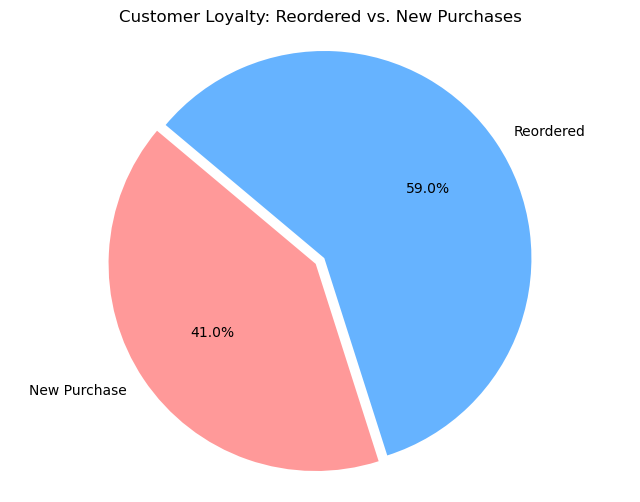

In [291]:
labels = ['New Purchase', 'Reordered']
sizes = [reorder_counts[0], reorder_counts[1]]
colors = ['#ff9999', '#66b3ff']  # Soft red and blue

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0))
plt.title('Customer Loyalty: Reordered vs. New Purchases')
plt.axis('equal') 
plt.show()

#### Reordered are slightly higher then the New purchase 

In [300]:
#Basket analysis for the produce department as it is highest order department 
produce_orders = df[df['department'].str.contains('produce', case=False, na=False)]['order_id'].unique().compute()


In [301]:
items_bought_with_produce_orders= df[df['order_id'].isin(produce_orders)]

In [304]:
companion_produce = items_bought_with_produce_orders[~items_bought_with_produce_orders['department'].str.contains('produce', case=False, na=False)]

In [342]:
produce_companion = companion_produce['product_name'].value_counts().compute().head(20)
print("--- Top Products Bought Alongside produce ---")
print(produce_companion)

--- Top Products Bought Alongside produce ---
product_name
air fresheners candles            762
asian foods                      9058
baby accessories                  412
baby bath body care               388
baby food formula               20086
bakery desserts                  1602
baking ingredients              16393
baking supplies decor            1067
beauty                            264
beers coolers                    1076
body lotions soap                1414
bread                           31066
breakfast bakery                12510
breakfast bars pastries          3205
bulk dried fruits vegetables      896
bulk grains rice dried goods     1005
buns rolls                       5709
butter                          13406
candy chocolate                 13216
canned fruit applesauce          4650
Name: count, dtype: int64


When analyzing products frequently purchased alongside produce, it is observed that essential grocery categories dominate the basket. Items such as bread, baby food formula, baking ingredients, butter, and breakfast bakery products are most commonly co-purchased with produce, indicating that customers typically buy produce as part of their routine grocery shopping trips rather than standalone purchases.

This pattern highlights strong cross-category buying behavior in everyday essentials, especially in fresh food, breakfast items, and household staples, which can be leveraged for bundling and targeted promotions.

### Time Taken to reorder

In [362]:
Time_to_reorder = df['reorder_gap_days'].value_counts().compute()
Time_to_reorder = Time_to_reorder .sort_values(ascending=False).reset_index()

In [365]:
Time_to_reorder

,reorder_gap_days,count
0,7.0,214126
1,30.0,210814
2,6.0,155685
3,0.0,152015
4,5.0,129089
5,4.0,126250
6,8.0,118722
7,3.0,113263
8,2.0,88737
9,9.0,75120


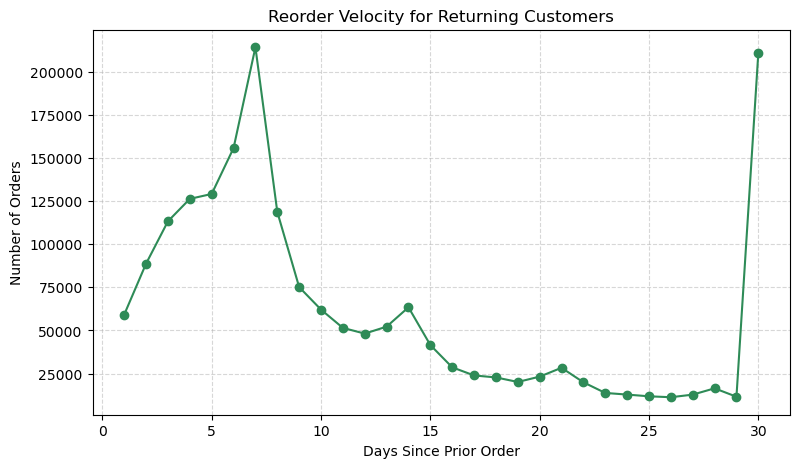

In [371]:
returning_data = Time_to_reorder[Time_to_reorder['reorder_gap_days'] > 0].sort_values('reorder_gap_days')

plt.figure(figsize=(9, 5))
plt.plot(returning_data['reorder_gap_days'], returning_data['count'], 
         marker='o', linestyle='-', color='#2e8b57')

plt.title('Reorder Velocity for Returning Customers')
plt.xlabel('Days Since Prior Order')
plt.ylabel('Number of Orders')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

There is a steady increase in reorder activity from Day 1, with a sharp peak observed around Day 7, indicating strong weekly purchasing behavior. A smaller but noticeable secondary peak appears around Day 14, suggesting a bi-weekly shopping pattern among customers. The sharp rise at the end is due to the dataset being capped at 30 days.

Overall, the pattern clearly indicates that customers tend to follow weekly and semi-monthly shopping cycles, which can be leveraged for timely marketing campaigns, reminders, and personalized offers.

### User Segmentation
- Grouping users into New(1-5 orders),
- Regular (6-20)
- Loyal (20+ orders)

In [337]:
user_order_counts = df.groupby('user_id')['order_number'].max()

In [338]:
def segment_user(count):
    if count <= 5:
        return 'New'
    elif count <= 20:
        return 'Regular'
    else:
        return 'Loyal'


user_segments = user_order_counts.map(segment_user, meta=('order_number', 'object'))
final_segmentation = user_segments.value_counts().compute()

In [339]:
print(final_segmentation)

order_number
Loyal      27323
New        33907
Regular    44043
Name: count, dtype: int64


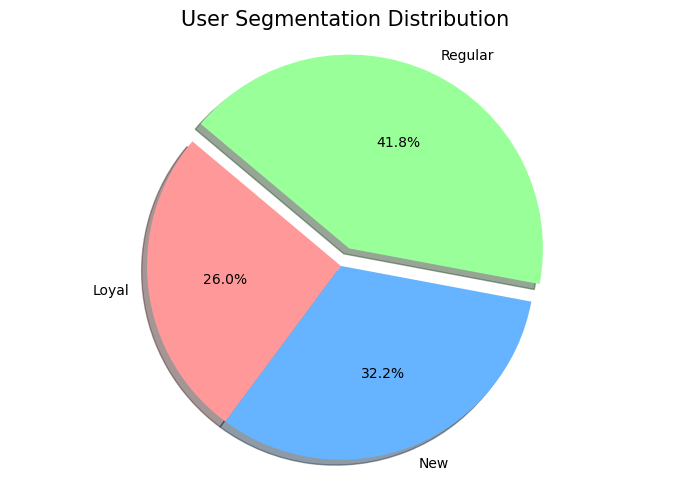

In [341]:
labels = final_segmentation.index
sizes = final_segmentation.values


colors = ['#ff9999','#66b3ff','#99ff99'] 
explode = (0, 0, 0.1)  

plt.figure(figsize=(7, 5))
plt.pie(sizes, 
        explode=explode, 
        labels=labels, 
        colors=colors, 
        autopct='%1.1f%%', 
        shadow=True, 
        startangle=140)

# 4. Add title and show
plt.title('User Segmentation Distribution', fontsize=15)
plt.axis('equal') 
plt.tight_layout()
plt.show()

Users were segmented based on their total number of orders into three categories: New (≤5 orders), Regular (6–20 orders), and Loyal (>20 orders). The distribution shows that 41.8% of users are Regular, making it the largest segment, followed by 32.2% New users and 26.0% Loyal users.

This indicates that a significant portion of users are moderately engaged, with a strong opportunity to convert Regular users into Loyal customers. At the same time, the relatively high share of New users suggests continuous user acquisition, but also highlights the need for early retention strategies to prevent drop-off.

### Recommendations for Business Growth
- Target Mid-Week Sales: Since most orders happen around the middle of the week (with an average day of week around 2.74), you should launch "Mid-Week Flash Sales" on Tuesdays and Wednesdays to boost volume during your peak traffic period.

- Morning Marketing Push: Most customers shop around 1:30 PM (hour 13.44). To capture this traffic, sending promotional emails or app notifications around 10:00 AM  at the top of their minds (and inboxes) when they start their lunch-break shopping.

- Shorten the Reorder Gap: The average customer waits about 11 days to buy again. To increase revenue, we can  bring this down to 7 or 8 days by sending "We miss you" coupons or reminders for "frequently bought" essentials exactly one week after their last purchase.

- Bundle Across Departments: Customers are already buying from many different departments. we can increase the "Add to Cart" count by suggesting items from different categories—for example, if they buy "Baking Ingredients" (Pantry), suggest "Butter" (Dairy) or "Fresh Fruits" (Produce).

- Focus on First-Time Buyers: data showed 124,342 first-time orders (noted as nulls in the prior order column). These customers are critical. Offer them a "Second Purchase Discount" immediately after their first delivery to turn them into loyal, repeat shoppers.

##### I analyzed around 2 million rows of data using big-data tool Dask . From the insights, I found that we can grow revenue by encouraging customers to shop again sooner (reducing the average 11-day gap between purchases) and by better targeting marketing around peak activity time, especially around 1:30 PM.